# Диффузия двух веществ



Классическое уравнение диффузии:

$$
\frac{\partial u(\mathbf{x}, t)}{\partial t} = D \,\Delta u(\mathbf{x}, t)
$$

где $u(\mathbf{x}, t)$ – концентрация в точке $\mathbf{x}$ в момент $t$, $D > 0$ – коэффициент диффузии.

В двумерном случае $\mathbf{x} = (x, y)$, поэтому

$$
\Delta u =
\frac{\partial^2 u}{\partial x^2} +
\frac{\partial^2 u}{\partial y^2}
$$

Пусть имеется прямоугольная сетка с шагом $h=1$. Лапласиан функции может быть вычислен через кросс-корреляцию:

$$
\Delta_h u = u * K_{\Delta}
$$

где ядро

$$
K_{\Delta} =
\begin{bmatrix}  
0 & 1 & 0 \\  
1 & -4 & 1 \\  
0 & 1 & 0  
\end{bmatrix}
$$

При этом, для каждой клетки $(i,j)$ на временно́м шаге $n$ получим значение

$$
\Delta_h u^{(n)}_{i,j} = u_{i+1,j}^n + u_{i-1,j}^n + u_{i,j+1}^n + u_{i,j-1}^n - 4u_{i,j}^n 
$$

Производную по времени заменяем разностью

$$
\frac{∂ u}{∂ t} = \frac{u^{(n)} - u^{(n-1)}}{\delta t} 
$$

При $\delta t = 1$ для каждой клетки $(i,j)$

$$
\frac{∂ u}{∂ t} = u_{i,j}^{(n)} - u_{i,j}^{(n-1)}
$$

Получаем итерационную формулу


$$
u_{i,j}^{(n)} \; ← \; u_{i,j}^{(n-1)} + D(u_{i+1,j}^n + u_{i-1,j}^n + u_{i,j+1}^n + u_{i,j-1}^n - 4u_{i,j}^n )
$$

или через кросс-корреляцию

$$
u^{(n)} \; ← \; u^{(n-1)} + D· u^{(n)} * K_{\Delta}
$$


## Инициализация клеток

In [1]:
import numpy as np

# Параметры области и схемы
N = 16                                 # базовый размер по высоте (и половине ширины)
H, W = N, 2 * N                        # высота H и ширина W прямоугольной решётки
alpha = 0.2                            # коэффициент диффузии-схемы (D * dt / h^2)
steps = 200                            # количество шагов анимации

speed = 1.0                            # множитель скорости анимации (1.0 — базовая)
base_interval = 50                     # базовый интервал между кадрами в миллисекундах
interval_ms = int(base_interval / speed)  # реальный интервал между кадрами с учётом speed

block_size = 4                         # размер квадрата с веществом

u1 = np.zeros((H, W), dtype=float)     # поле концентраций первого вещества
u2 = np.zeros((H, W), dtype=float)     # поле концентраций второго вещества

# Центры квадратов
cy = H // 2                            # вертикальный центр области
r0 = cy - block_size // 2              # верхняя граница квадрата по вертикали
r1 = r0 + block_size                   # нижняя граница квадрата по вертикали

cx_left = N // 2                       # горизонтальный центр левой половины области
c0_left = cx_left - block_size // 2    # левая граница левого квадрата
c1_left = c0_left + block_size         # правая граница левого квадрата
u1[r0:r1, c0_left:c1_left] = 1.0       # заполняем левый квадрат первым веществом

cx_right = N + N // 2                  # горизонтальный центр правой половины области
c0_right = cx_right - block_size // 2  # левая граница правого квадрата
c1_right = c0_right + block_size       # правая граница правого квадрата
u2[r0:r1, c0_right:c1_right] = 1.0     # заполняем правый квадрат вторым веществом

# Визуализация

## Логарифмирование

Логарифмирование значений цвета для красоты:

$$
v=\frac{\ln(1+ku)​}{\ln(1+k)} 
$$

Такое преобразование делает тусклые клетки более яркими, но диапазон остается $[0, 1]$.

Будем использовать `np.log1p(x)`вместо `np.log(1 + x)`, чтобы меньше терять точность, когда `x` очень мал. `np.log1p(x)` вычисляет $\ln(1+x)$, но численно устойчиво для маленьких $x$.



In [2]:
def log_scale(u, eps=1e-6, k=50.0):
    u_clip = np.clip(u, 0.0, None)          # обрезка значений снизу
    v = np.log1p(k * u_clip) / np.log1p(k)
    return v

## Концентрации -> цвета

In [3]:
def make_rgb(u1, u2, base_gray=0.1):
    """Преобразуем два поля концентраций в RGB-картинку так,
    чтобы пиксели с веществами не были темнее фонового серого.
    """
    # логарифмическое шкалирование концентраций
    r = log_scale(u1)  # [0, 1]
    b = log_scale(u2)  # [0, 1]

    # "чистый" цвет от веществ (без фона)
    color = np.zeros((H, W, 3), dtype=float)
    color[..., 0] = r      # красный канал — вещество 1
    color[..., 2] = b      # синий канал — вещество 2

    # добавляем цвет поверх серого фона:
    # при r=b=0 получаем ровно [base_gray, base_gray, base_gray],
    # при r или b → 1 получаем до [1, 0, 1] и т.д.
    rgb = base_gray + (1.0 - base_gray) * color

    return rgb


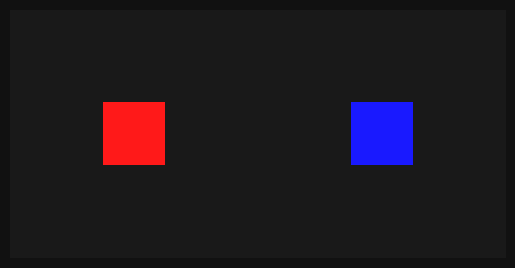

In [4]:
import matplotlib.pyplot as plt

%matplotlib inline
fig, ax = plt.subplots()
img = make_rgb(u1, u2)
im = ax.imshow(img, interpolation="nearest")
ax.set_axis_off()
fig.patch.set_facecolor("#111111")
plt.show()

# Шаг диффузии

Для того, чтобы вычислять кросс-корреляцию, можно воспользоваться функцией `correlate2d()` из модуля `signal` библиотеки `scipy`. В качестве граничного условия будем использовать условие Неймана, чтобы моделировать ограниченное пространство. Для этого зададим параметры `mode='same'`, чтобы результатом преобразования была матрица того же размера, что и входная матрица, `boundary='symm'`, чтобы при вычислении значений на границах матрицы добавлялась рамка вокруг всей матрицы, значения которых совпадают с граничными значениями.

In [5]:
from scipy.signal import correlate2d

def diffusion_step_box(u, D, kernel=None):
    """
    Один шаг диффузии в замкнутом ящике (без потока через границы).
    Условия Неймана: производная по нормали на границе = 0.

    Реализовано через кросс-корреляцию с ядром лапласиана
    и симметричное продолжение массива (boundary='symm'),
    что эквивалентно "зеркальным" призрачным ячейкам.
    """
    if kernel is None:
        laplacian_kernel = np.array([
            [0.0,  1.0, 0.0],
            [1.0, -4.0, 1.0],
            [0.0,  1.0, 0.0]
        ], dtype=float)

    laplacian = correlate2d(u, laplacian_kernel,
                            mode='same',      # размер выхода = размер входа
                            boundary='symm')  # зеркальное продолжение → Neumann-like BC
    return u + D * laplacian

Альтернативный вариант без `scipy`:

In [6]:
# def diffusion_step_box(u, D):
#     """
#     Один шаг диффузии в замкнутом ящике (без потока через границы).
#     Условия Неймана: производная по нормали на границе = 0.
#     Реализуем через зеркальное расширение массива (mode='edge').
#     """
#     # Добавляем по одному призрачному слою с каждой стороны,
#     # где значения на границе просто копируются.
#     u_p = np.pad(u, pad_width=1, mode='edge')

#     center = u_p[1:-1, 1:-1]
#     up     = u_p[:-2, 1:-1]
#     down   = u_p[2:, 1:-1]
#     left   = u_p[1:-1, :-2]
#     right  = u_p[1:-1, 2:]

#     laplacian = up + down + left + right - 4 * center
#     return u + D * laplacian

# Симуляция

In [7]:
from matplotlib.animation import FuncAnimation

%matplotlib qt
fig, ax = plt.subplots(figsize=(12, 6))
img = make_rgb(u1, u2)
im = ax.imshow(img, interpolation="nearest")
ax.set_axis_off()
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

def update(frame, u1, u2, im, ax):
    # считаем новые значения
    u1_new = diffusion_step_box(u1, alpha)
    u2_new = diffusion_step_box(u2, alpha)

    # обновляем массивы *in-place*, без смены ссылки
    u1[:] = u1_new
    u2[:] = u2_new

    img = make_rgb(u1, u2)
    im.set_data(img)
    return [im]

ani = FuncAnimation(
    fig,
    update,
    frames=steps,
    fargs=(u1, u2, im, ax),   # <- передаём всё нужное в обновляющую функцию
    interval=interval_ms,
    blit=False
)

plt.show()


# Запись видео

## Генерация всех кадров в PNG

In [32]:
import os
import matplotlib.pyplot as plt

# -------- Параметры --------
FPS     = 30                 # 30 fps (понадобится при сборке в ffmpeg)
FRAMES  = 1800                # сколько шагов диффузии сохранить
FRAMES_DIR = "./frames_diffusion_2"   # сюда сложим PNG
os.makedirs(FRAMES_DIR, exist_ok=True)

# Убедимся, что у нас есть независимая копия начального состояния
u1_vid = u1.copy()
u2_vid = u2.copy()

H, W = u1_vid.shape  # размеры решётки

# ---------- Настройка разрешения под 4K ----------

TARGET_WIDTH_PX  = 3840
TARGET_HEIGHT_PX = int(round(TARGET_WIDTH_PX * H / W))

# пусть высота тоже будет чётной
if TARGET_HEIGHT_PX % 2 == 1:
    TARGET_HEIGHT_PX += 1

DPI = 300  # можно менять, лишь бы TARGET_* = FIGSIZE * DPI
FIGWIDTH  = TARGET_WIDTH_PX  / DPI
FIGHEIGHT = TARGET_HEIGHT_PX / DPI

plt.ioff()  # без интерактива
fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGHEIGHT))
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Без полей: картинка занимает всю фигуру
ax.set_position([0, 0, 1, 1])

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Первое изображение (кадр 0)
img0 = make_rgb(u1_vid, u2_vid)
im = ax.imshow(img0, interpolation="nearest", aspect="equal")

# ------- Сохранение кадров -------

# Кадр 0: начальное состояние
for i in range(5):
    frame_path = os.path.join(FRAMES_DIR, f"frame_{i:04d}.png")
    fig.savefig(frame_path, dpi=DPI)

# Дальше шаги диффузии
for n in range(5, FRAMES + 1):
    # Один шаг диффузии для обоих веществ
    u1_vid = diffusion_step_box(u1_vid, alpha)
    u2_vid = diffusion_step_box(u2_vid, alpha)

    img = make_rgb(u1_vid, u2_vid)
    im.set_data(img)

    frame_path = os.path.join(FRAMES_DIR, f"frame_{n:04d}.png")
    fig.savefig(frame_path, dpi=DPI)

plt.close(fig)
print(f"Сохранены {FRAMES+1} кадров в папку {FRAMES_DIR}")


Сохранены 1801 кадров в папку ./frames_diffusion_2


## Сборка в MKV

In [33]:
import os
import subprocess
import imageio_ffmpeg

FRAMES_DIR   = "./frames_diffusion_2"
OUTPUT_FFV1  = "./outputs/diffusion_box_two_substances-ffv_1.mkv"
FPS          = 30

os.makedirs(os.path.dirname(OUTPUT_FFV1), exist_ok=True)

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
input_pattern = os.path.join(FRAMES_DIR, "frame_%04d.png")

cmd = [
    ffmpeg_exe,
    "-y",
    "-framerate", str(FPS),
    "-i", input_pattern,
    "-c:v", "ffv1",   # lossless-кодек
    "-pix_fmt", "rgb24",  # остаёмся в RGB, без перехода в YUV
    OUTPUT_FFV1,
]

print("Запускаю ffmpeg (FFV1)...")
print(" ".join(cmd))
subprocess.run(cmd, check=True)
print("Готово:", OUTPUT_FFV1)

Запускаю ffmpeg (FFV1)...
c:\Users\ordevoir\miniconda3\envs\marl\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -framerate 30 -i ./frames_diffusion_2\frame_%04d.png -c:v ffv1 -pix_fmt rgb24 ./outputs/diffusion_box_two_substances-ffv_1.mkv
Готово: ./outputs/diffusion_box_two_substances-ffv_1.mkv


## Сборка в GIF

In [11]:
import os
import subprocess
import imageio_ffmpeg

FRAMES_DIR  = "./outputs/frames_diffusion_2"
OUTPUT_GIF  = "./outputs/diffusion_box_two_substances_4.gif"
FPS         = 30

# Желаемое разрешение GIF
TARGET_WIDTH  = 1000
TARGET_HEIGHT = 500  # задай что нужно

os.makedirs(os.path.dirname(OUTPUT_GIF), exist_ok=True)

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
input_pattern = os.path.join(FRAMES_DIR, "frame_%04d.png")
palette_path  = os.path.join(FRAMES_DIR, "palette.png")

# ----- 1. Генерация палитры -----
cmd_palette = [
    ffmpeg_exe,
    "-y",
    "-framerate", str(FPS),
    "-i", input_pattern,
    "-vf", f"fps={FPS},scale={TARGET_WIDTH}:{TARGET_HEIGHT}:flags=lanczos,palettegen",
    palette_path,
]

print("Генерирую палитру для GIF...")
print(" ".join(cmd_palette))
subprocess.run(cmd_palette, check=True)

# ----- 2. Сборка GIF с палитрой -----
cmd_gif = [
    ffmpeg_exe,
    "-y",
    "-framerate", str(FPS),
    "-i", input_pattern,
    "-i", palette_path,
    "-lavfi", f"fps={FPS},scale={TARGET_WIDTH}:{TARGET_HEIGHT}:flags=lanczos,paletteuse",
    "-loop", "0",   # 0 = бесконечный цикл
    OUTPUT_GIF,
]

print("Собираю GIF...")
print(" ".join(cmd_gif))
subprocess.run(cmd_gif, check=True)
print("Готово:", OUTPUT_GIF)


Генерирую палитру для GIF...
c:\Users\ordevoir\miniconda3\envs\marl\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -framerate 30 -i ./outputs/frames_diffusion_2\frame_%04d.png -vf fps=30,scale=1000:500:flags=lanczos,palettegen ./outputs/frames_diffusion_2\palette.png
Собираю GIF...
c:\Users\ordevoir\miniconda3\envs\marl\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -framerate 30 -i ./outputs/frames_diffusion_2\frame_%04d.png -i ./outputs/frames_diffusion_2\palette.png -lavfi fps=30,scale=1000:500:flags=lanczos,paletteuse -loop 0 ./outputs/diffusion_box_two_substances_4.gif
Готово: ./outputs/diffusion_box_two_substances_4.gif


## Сборка в MP4

In [35]:
import os
import subprocess
import imageio_ffmpeg

FRAMES_DIR   = "./frames_diffusion_2"
OUTPUT_MP4   = "./outputs/diffusion_box_two_substances-hq_2.mp4"
FPS          = 30

os.makedirs(os.path.dirname(OUTPUT_MP4), exist_ok=True)

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
input_pattern = os.path.join(FRAMES_DIR, "frame_%04d.png")

# Вариант: очень высокое качество (визуально почти без потерь)
cmd = [
    ffmpeg_exe,
    "-y",
    "-framerate", str(FPS),   # частота кадров на входе
    "-i", input_pattern,      # кадры frame_0000.png, frame_0001.png, ...
    "-c:v", "libx264",        # кодек H.264
    "-preset", "slow",        # скорость/качество кодирования ("veryslow", "slow", "medium"...)
    "-crf", "10",             # качество: 0–51, чем МЕНЬШЕ, тем лучше (10 – очень хорошее)
    "-pix_fmt", "yuv420p",    # совместимый формат для большинства плееров
    OUTPUT_MP4,
]

print("Запускаю ffmpeg (MP4 H.264, high quality)...")
print(" ".join(cmd))
subprocess.run(cmd, check=True)
print("Готово:", OUTPUT_MP4)

Запускаю ffmpeg (MP4 H.264, high quality)...
c:\Users\ordevoir\miniconda3\envs\marl\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -y -framerate 30 -i ./frames_diffusion_2\frame_%04d.png -c:v libx264 -preset slow -crf 10 -pix_fmt yuv420p ./outputs/diffusion_box_two_substances-hq_2.mp4
Готово: ./outputs/diffusion_box_two_substances-hq_2.mp4


# Диффузия одно вещества

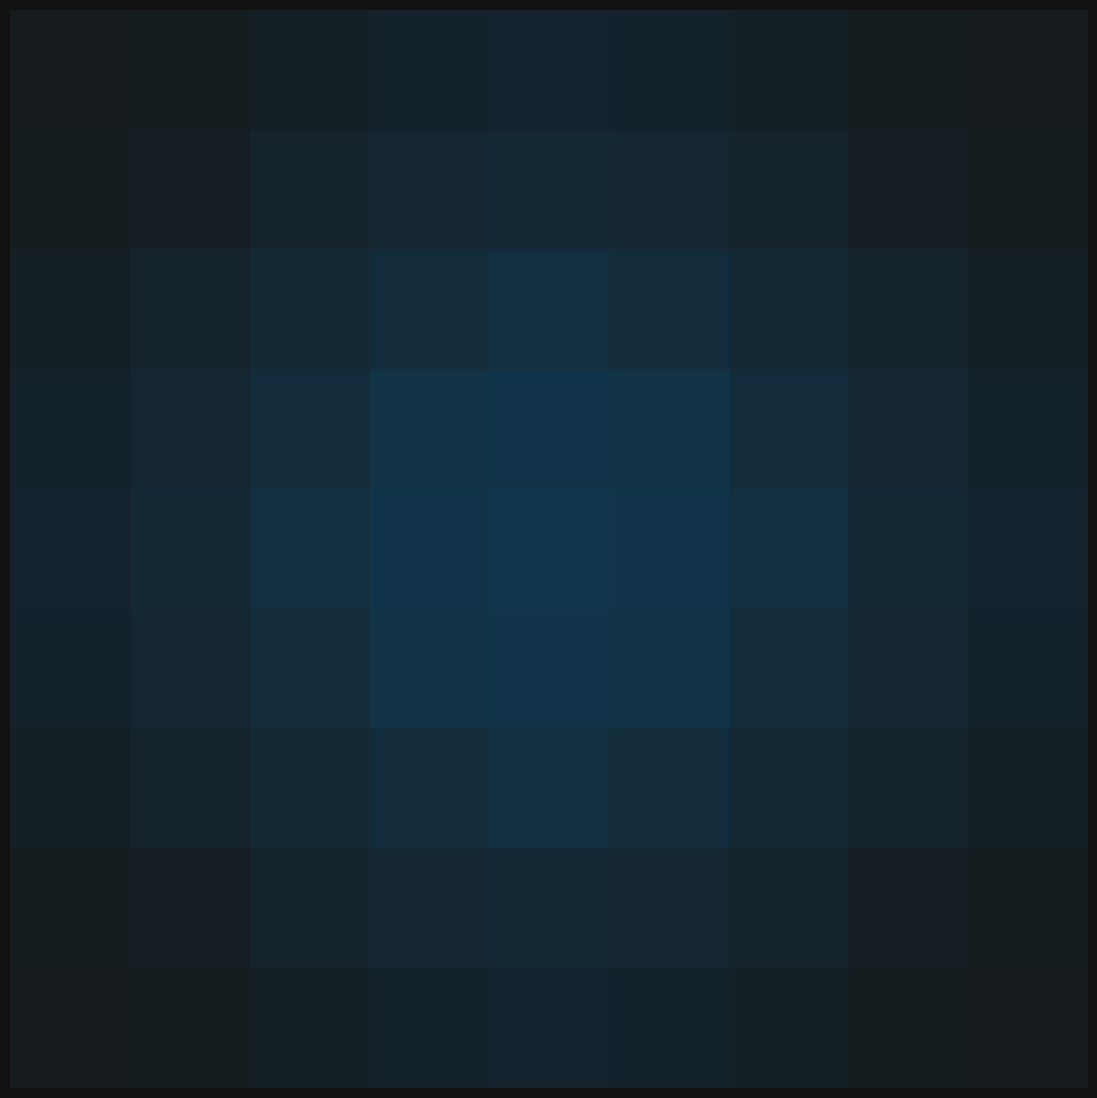

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d

# --------- Параметры ---------
BLOCK = 3              # размер квадрата с веществом (BLOCK x BLOCK)
SCALE = 3              # во сколько раз область больше квадрата
N = BLOCK * SCALE   # размер области N x N (делаем нечётной)

H = W = N
alpha = 0.2            # коэффициент диффузии
steps = 13              # сколько шагов диффузии делаем

# --------- Поле концентраций и инициализация ---------
u = np.zeros((H, W), dtype=float)

cy, cx = H // 2, W // 2          # центр области
half = BLOCK // 2
r0, r1 = cy - half, cy - half + BLOCK
c0, c1 = cx - half, cx - half + BLOCK

u[r0:r1, c0:c1] = 1.0            # квадрат BLOCK x BLOCK в центре

# --------- Цвета: фон и вещество ---------
def hex_to_rgb01(hex_color: str) -> np.ndarray:
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return np.array([r, g, b], dtype=float) / 255.0

# СYBERPUNK
# FG_COLOR = hex_to_rgb01("#0079C5A3")   # цвет фона
# BG_COLOR = hex_to_rgb01("#4E105A")   # цвет вещества

FG_COLOR = hex_to_rgb01("#009DFF")   # цвет фона
BG_COLOR = hex_to_rgb01("#171717")   # цвет вещества

def make_rgb(u, bg=BG_COLOR, fg=FG_COLOR):
    """Линейная интерполяция между цветом фона и вещества по концентрации u."""
    u_clip = np.clip(u, 0.0, 1.0)
    rgb = bg[None, None, :] + u_clip[..., None] * (fg - bg)[None, None, :]
    return np.clip(rgb, 0.0, 1.0)

# --------- Шаг диффузии ---------
def diffusion_step_box(u, D):
    """Диффузия с граничными условиями Неймана (boundary='symm')."""
    laplacian_kernel = np.array([
        [0.0,  1.0, 0.0],
        [1.0, -4.0, 1.0],
        [0.0,  1.0, 0.0]
    ], dtype=float)

    laplacian = correlate2d(
        u,
        laplacian_kernel,
        mode='same',
        boundary='symm'
    )
    return u + D * laplacian

# --------- Прогон шагов диффузии ---------
for _ in range(steps):
    u = diffusion_step_box(u, alpha)

# --------- Визуализация итогового состояния ---------
fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(make_rgb(u), interpolation="nearest")
ax.axis("off")
fig.patch.set_facecolor("#111111")
plt.savefig('./outputs/diffusion_21.png', bbox_inches='tight', pad_inches=0)
plt.show()


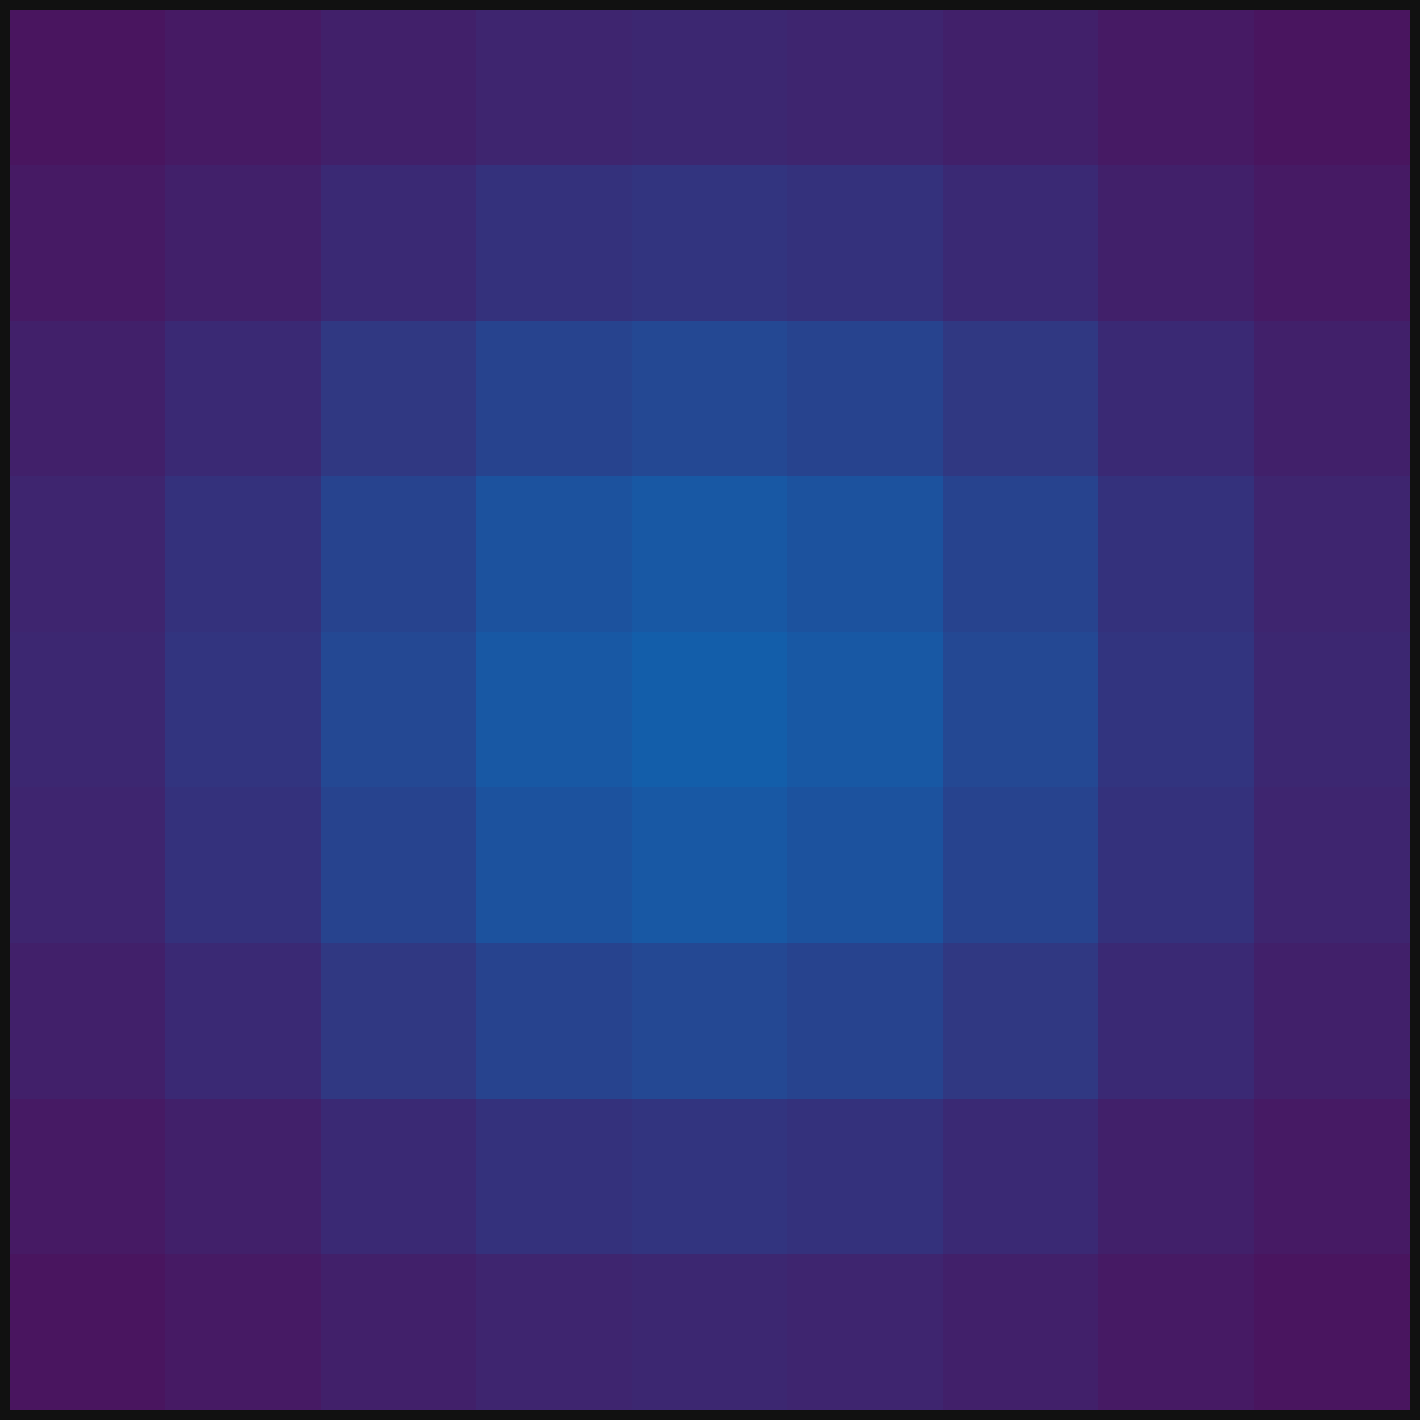

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d

# --------- Параметры ---------
BLOCK = 5              # размер квадрата с веществом (BLOCK x BLOCK)
SCALE = 2              # во сколько раз область больше квадрата
N = BLOCK * SCALE - 1  # размер области N x N (делаем нечётной)

H = W = N
alpha = 0.2            # коэффициент диффузии (diffusion coefficient)
steps = 7              # сколько шагов диффузии делаем

# --------- Поле концентраций и инициализация ---------
u = np.zeros((H, W), dtype=float)

cy, cx = H // 2, W // 2          # центр области
half = BLOCK // 2
r0, r1 = cy - half, cy - half + BLOCK
c0, c1 = cx - half, cx - half + BLOCK

u[r0:r1, c0:c1] = 1.0            # квадрат BLOCK x BLOCK в центре

# --------- Цвета: фон и вещество ---------
def hex_to_rgb01(hex_color: str) -> np.ndarray:
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return np.array([r, g, b], dtype=float) / 255.0

FG_COLOR = hex_to_rgb01("#0079C5A3")   # цвет фона
BG_COLOR = hex_to_rgb01("#4E105A")   # цвет вещества

def make_rgb(u, bg=BG_COLOR, fg=FG_COLOR):
    """Линейная интерполяция между цветом фона и вещества по концентрации u."""
    u_clip = np.clip(u, 0.0, 1.0)
    rgb = bg[None, None, :] + u_clip[..., None] * (fg - bg)[None, None, :]
    return np.clip(rgb, 0.0, 1.0)

# --------- Шаг диффузии ---------
def diffusion_step_box(u, D):
    """Диффузия с граничными условиями Неймана (Neumann boundary conditions) (boundary='symm')."""
    laplacian_kernel = np.array([
        [0.0,  1.0, 0.0],
        [1.0, -4.0, 1.0],
        [0.0,  1.0, 0.0]
    ], dtype=float)

    laplacian = correlate2d(
        u,
        laplacian_kernel,
        mode='same',
        boundary='symm'
    )
    return u + D * laplacian

# --------- Прогон шагов диффузии ---------
for _ in range(steps):
    u = diffusion_step_box(u, alpha)

# --------- Визуализация итогового состояния ---------
fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(make_rgb(u), interpolation="nearest")
ax.axis("off")

# Убираем все отступы и рамки
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.set_position([0, 0, 1, 1])

fig.patch.set_facecolor("#111111")
plt.savefig('./outputs/diffusion_10.png', bbox_inches='tight', pad_inches=0)
plt.show()

TypeError: Figure.savefig() takes 2 positional arguments but 3 were given

<Figure size 640x480 with 0 Axes>